# Seasonal surface water (2000) per Ethnologue polygon — FIXED version

Re-does the seasonal-water-2000 calculation from [`waterchange_ethnologue.ipynb`](waterchange_ethnologue.ipynb) with the same two corrections applied in [`forestloss_ethnologue_fixed.ipynb`](forestloss_ethnologue_fixed.ipynb):

**1. Latitude-aware pixel area.** The mosaic is in EPSG:4326 at `res=(0.01°, 0.01°)`. Each cell is ~1 km × 1 km only near the equator and shrinks with `cos(latitude)` toward the poles. Original code multiplied pixel counts by a flat `0.01` (the area of a *native* 100 m pixel, not a 0.01° cell), which underestimated by ~100× and was latitude-biased. Here we compute each cell's actual km² and weight by it.

**2. Keep the fraction instead of truncating with `> 0`.** Source band is binary 0/1 (1 = seasonal water in 2000) at native 100 m, but `merge(..., resampling=Resampling.average)` aggregates to ~1 km producing fractional values in `[0, 1]` = share of native sub-pixels classified as seasonal water. The original code did `(mosaic[0] > 0).astype(uint8)`, which collapsed any cell with *any* seasonal water to 1 — so a 1 km cell with 1% water counted the same as one with 100%. Here we keep the fractions.

**Output:**
- `seasonalwater_2000_km2` = sum over cells of `(seasonal_frac × cell_area_km2)` = km² of seasonal-water-equivalent area in the polygon.

In [2]:
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
from rasterstats import zonal_stats

import matplotlib.pyplot as plt
from rasterio.plot import show

In [3]:
base_path    = Path("C:/Users/juami/Dropbox/RAships/2-Folklore-Nathan-Project/EA-Maps-Nathan-project/Measures_work")
poscol_path  = base_path / "data" / "raw" / "ethnologue" / "ancestral_characteristics_database_language_level" / "Ethnologue_16_shapefile" / "langa_no_overlap_biggest_clean.shp"
water_path   = base_path / "maps" / "raw" / "Water_surface"
seasonal_dir = water_path / "seasonal_water_2000"

ethnologue = gpd.read_file(poscol_path)
ethnologue = ethnologue[["ID", "geometry"]]
print(f"Number of features: {len(ethnologue)}")

Number of features: 7087


In [4]:
# --- Helpers (mirroring forestloss_ethnologue_fixed.ipynb) ----------------
def mosaic_1km(folder: Path):
    """Merge all .tif tiles in `folder` to ~1 km resolution using average resampling."""
    files = sorted(glob(str(folder / "*.tif")))
    srcs  = [rasterio.open(fp) for fp in files]
    mos, trans = merge(srcs, res=(0.01, 0.01), resampling=Resampling.average)
    crs = srcs[0].crs
    for s in srcs:
        s.close()
    return mos[0].astype(np.float32), trans, crs

def pixel_area_km2_grid(transform, shape):
    """(rows, cols) array of per-cell area in km² for an EPSG:4326 transform.
    Spherical-Earth approximation: cell area at latitude φ is
        (R * dλ * cosφ) * (R * dφ),  dλ, dφ in radians.
    """
    rows, cols = shape
    R_km  = 6371.0088
    dlat  = abs(transform.e)
    dlon  = abs(transform.a)
    lat_top = transform.f
    lat_centers = lat_top + (np.arange(rows) + 0.5) * transform.e
    lat_rad = np.deg2rad(lat_centers)
    dy_km = R_km * np.deg2rad(dlat)
    dx_km = R_km * np.cos(lat_rad) * np.deg2rad(dlon)
    area_row = (dx_km * dy_km).astype(np.float32)
    return np.broadcast_to(area_row[:, None], (rows, cols)).astype(np.float32)

def zonal_sum_on_array(array, transform, crs, polygons):
    """Write a float32 array to an in-memory GeoTIFF and zonal-sum it over `polygons`."""
    with MemoryFile() as mf:
        with mf.open(
            driver="GTiff",
            height=array.shape[0],
            width=array.shape[1],
            count=1,
            dtype="float32",
            transform=transform,
            crs=crs,
            nodata=np.float32(-9999.0),
        ) as dst:
            arr = np.where(np.isnan(array), np.float32(-9999.0), array).astype(np.float32)
            dst.write(arr, 1)
        stats = zonal_stats(polygons, mf.name, stats=["sum"], geojson_out=True)
    return [s["properties"]["sum"] for s in stats]

In [5]:
# --- Build seasonal water 2000 mosaic (values 0..1 = fraction of sub-pixels) ---
seasonal, sw_trans, sw_crs = mosaic_1km(seasonal_dir)
print("seasonal mosaic shape:", seasonal.shape, "| crs:", sw_crs)
print("value range:", float(seasonal.min()), "-", float(seasonal.max()),
      "| mean:", float(seasonal.mean()))

ethnologue = ethnologue.to_crs(sw_crs)

seasonal mosaic shape: (17000, 36000) | crs: EPSG:4326
value range: 0.0 - 1.0 | mean: 0.0007086193072609603


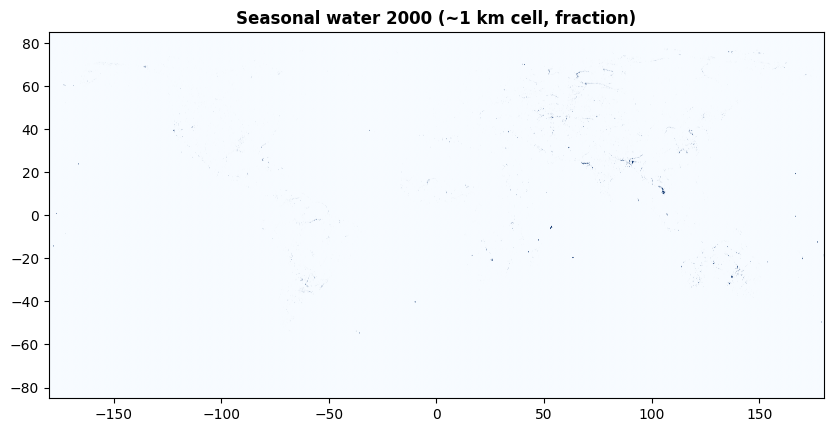

In [6]:
# Quick visual sanity check
fig, ax = plt.subplots(figsize=(10, 5))
show(seasonal, transform=sw_trans, ax=ax,
     title="Seasonal water 2000 (~1 km cell, fraction)",
     cmap="Blues", vmin=0, vmax=0.5)
plt.show()

In [7]:
# --- Per-cell area in km² (latitude-aware) ---------------------------------
area_km2 = pixel_area_km2_grid(sw_trans, seasonal.shape)
print("area_km2 range:", float(area_km2.min()), "-", float(area_km2.max()),
      "| mean:", float(area_km2.mean()))

area_km2 range: 0.10785570740699768 - 1.2364345788955688 | mean: 0.8302695155143738


In [8]:
# --- Weighted raster: km² of seasonal water per cell ----------------------
# Keep the fraction (don't threshold with > 0). Multiply by lat-aware cell area.
seasonal_frac     = np.clip(seasonal, 0.0, 1.0).astype(np.float32)
seasonal_km2_cell = (seasonal_frac * area_km2).astype(np.float32)

print("Global total seasonal water 2000 (sanity):",
      float(seasonal_km2_cell.sum()) / 1e6, "M km²")

Global total seasonal water 2000 (sanity): 0.4255101875 M km²


In [9]:
# --- Zonal sum -------------------------------------------------------------
ethnologue["seasonalwater_2000_km2"] = zonal_sum_on_array(
    seasonal_km2_cell, sw_trans, sw_crs, ethnologue
)
ethnologue[["ID", "seasonalwater_2000_km2"]].head()

,ID,seasonalwater_2000_km2
0,RUS-RUS,27180.416016
1,ENG-USA,10138.652344
2,POR-BRA,14804.072266
3,ENG-AUS,28072.556641
4,CMN-CHN,14911.619141


In [10]:
df = ethnologue[["ID", "seasonalwater_2000_km2"]]
print(len(df))
df.describe()

7087


,seasonalwater_2000_km2
count,7057.000000
mean,44.628057
std,661.678076
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,28072.556641


In [11]:
# Optional sanity check: compare to the original (un-fixed) measure if available
old_csv = water_path / "perm_loss_water.csv"
if old_csv.exists():
    df_old = pd.read_csv(old_csv)
    if "seasonalwater_2000_km2" in df_old.columns:
        cmp = df.merge(
            df_old[["id" if "id" in df_old.columns else "ID", "seasonalwater_2000_km2"]]
                .rename(columns={"id": "ID", "seasonalwater_2000_km2": "seasonalwater_2000_km2_old"}),
            on="ID", how="left",
        )
        cmp["ratio"] = cmp["seasonalwater_2000_km2"] / cmp["seasonalwater_2000_km2_old"]
        print(cmp[["seasonalwater_2000_km2", "seasonalwater_2000_km2_old", "ratio"]].describe())
    else:
        print("Old CSV does not have seasonalwater_2000_km2 — skipping comparison.")
else:
    print("Old CSV not found — skipping comparison.")

       seasonalwater_2000_km2  seasonalwater_2000_km2_old        ratio
count             7057.000000                 7057.000000  1219.000000
mean                44.628057                    0.450186   112.142786
std                661.678076                    7.529403    15.848366
min                  0.000000                    0.000000    37.720879
25%                  0.000000                    0.000000   110.287501
50%                  0.000000                    0.000000   118.493807
75%                  0.000000                    0.000000   122.160882
max              28072.556641                  446.590000   123.643398


In [12]:
out_path = water_path / "ethnologue_seasonalwater_2000_fixed.csv"
df.to_csv(out_path, index=False)
print("Exported", out_path)

Exported C:\Users\juami\Dropbox\RAships\2-Folklore-Nathan-Project\EA-Maps-Nathan-project\Measures_work\maps\raw\Water_surface\ethnologue_seasonalwater_2000_fixed.csv
